# EEG-CogState — Sprint 4 : Machine Learning & évaluation

**Objectif du Sprint 4** (cahier des charges) : entraîner un modèle fiable et l'évaluer honnêtement. **C'est le cœur scientifique du projet — jalon M1.**

## La règle d'or : validation PAR SUJET

Plusieurs epochs viennent du même sujet et partagent sa signature cérébrale. Si on mélangeait les epochs au hasard entre entraînement et test, le modèle « reconnaîtrait » le sujet au lieu d'apprendre l'état cognitif — et les scores seraient **faussement excellents**.

On évalue donc en **Leave-One-Subject-Out** : un sujet entier en test, les autres en entraînement. C'est la seule mesure honnête de la capacité à généraliser à un **nouvel** utilisateur.

Tout est dans `src/model.py`.

## 1. Imports et chargement des features

On charge le tableau produit au Sprint 3. **Prérequis** : avoir lancé le notebook 03 (qui crée `data/processed/features.csv`).

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, model

X, y, groups, feature_names = model.load_features()
print(f"Donnees chargees :")
print(f"  {X.shape[0]} epochs")
print(f"  {X.shape[1]} features")
print(f"  {len(np.unique(groups))} sujets : {sorted(np.unique(groups))}")
print(f"  classes : {sorted(np.unique(y))}")

Donnees chargees :
  1192 epochs
  294 features
  3 sujets : [np.int64(10), np.int64(11), np.int64(12)]
  classes : ['concentration', 'relaxation']


## 2. La référence naïve (baseline)

Avant d'entraîner quoi que ce soit, on calcule le score d'un classifieur
bête qui prédit toujours la classe majoritaire. **Notre modèle devra
faire nettement mieux que ça** pour être utile.

In [2]:
base = model.baseline_score(y)
print(f"Reference (toujours la classe majoritaire) : macro-F1 = {base:.3f}")
print("\nLe modele doit depasser ce score pour apporter de la valeur.")

Reference (toujours la classe majoritaire) : macro-F1 = 0.333

Le modele doit depasser ce score pour apporter de la valeur.


## 3. Évaluation par sujet (Leave-One-Subject-Out)

On entraîne et teste le modèle autant de fois qu'il y a de sujets.
À chaque tour, un sujet différent sert de test.

> Cette cellule peut prendre un moment (elle entraîne plusieurs modèles).

In [3]:
results = model.evaluate_loso(X, y, groups, verbose=True)
model.print_evaluation_report(results)

Validation Leave-One-Subject-Out sur 3 sujets :

  Sujet  10 en test : macro-F1 = 0.500 | accuracy = 1.000
  Sujet  11 en test : macro-F1 = 0.707 | accuracy = 0.715
  Sujet  12 en test : macro-F1 = 0.413 | accuracy = 0.705

RESULTATS GLOBAUX (validation par sujet)
  Macro-F1            : 0.784
  Exactitude equilibree: 0.784
  Exactitude          : 0.784

  Stabilite entre sujets (macro-F1) :
     moyenne = 0.540 | ecart-type = 0.151
     min = 0.413 | max = 0.707

  Matrice de confusion :
  (lignes = reel, colonnes = predit)
            concentr  relaxati
  concentrat       472       124
  relaxation       134       462


## 4. Matrice de confusion (visuelle)

La matrice de confusion montre où le modèle se trompe : quelles classes
il confond. La diagonale = les bonnes prédictions.

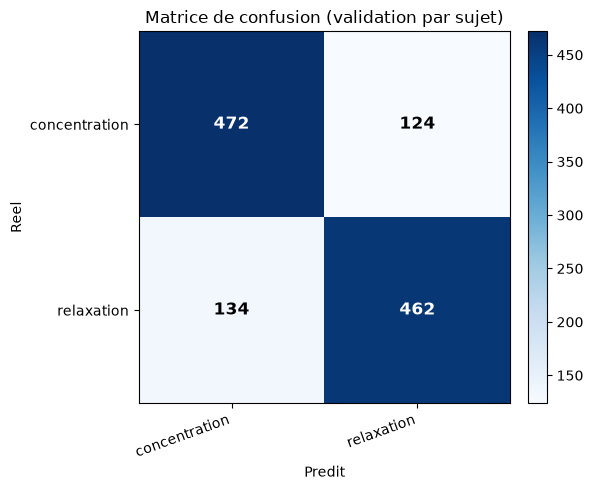

In [4]:
from sklearn.metrics import confusion_matrix

labels = results["labels"]
cm = confusion_matrix(results["y_true"], results["y_pred"], labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_yticklabels(labels)
ax.set_xlabel("Predit")
ax.set_ylabel("Reel")
ax.set_title("Matrice de confusion (validation par sujet)")

# Annoter chaque case avec le nombre
thresh = cm.max() / 2
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=12, fontweight="bold")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

## 5. Stabilité du modèle entre sujets

Un bon modèle est régulier : il marche à peu près aussi bien sur chaque
sujet. On visualise le score obtenu pour chaque sujet de test.

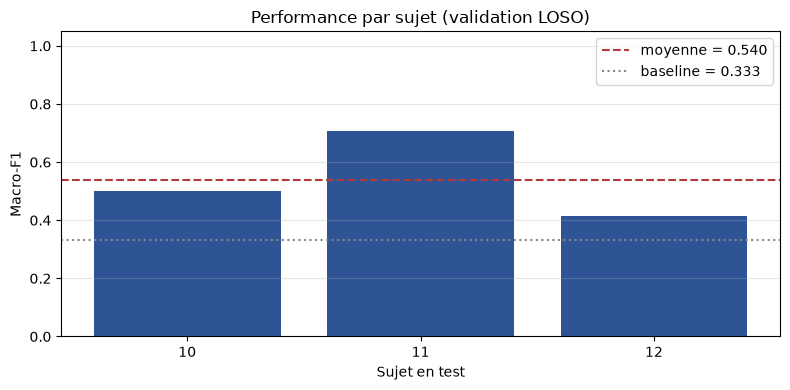

 subject  n_epochs  macro_f1  accuracy
      10       298     0.500     1.000
      11       596     0.707     0.715
      12       298     0.413     0.705


In [5]:
ps = results["per_subject"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(ps["subject"].astype(str), ps["macro_f1"], color="#2E5496")
ax.axhline(ps["macro_f1"].mean(), color="#B23A3A", linestyle="--",
           label=f"moyenne = {ps['macro_f1'].mean():.3f}")
ax.axhline(base, color="#888", linestyle=":", label=f"baseline = {base:.3f}")
ax.set_xlabel("Sujet en test")
ax.set_ylabel("Macro-F1")
ax.set_ylim(0, 1.05)
ax.set_title("Performance par sujet (validation LOSO)")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
fig.tight_layout()
plt.show()

print(ps.to_string(index=False))

## 6. Entraînement du modèle final

L'évaluation honnête est faite. On entraîne maintenant le modèle **final**
sur **toutes** les données, et on le sauvegarde. C'est ce modèle que
l'application web (Sprint 5) utilisera pour prédire l'état d'un nouveau fichier.

In [6]:
final_model, saved_path = model.train_final_model(X, y, save=True)
print("Modele final entraine sur", X.shape[0], "epochs.")
print("Sauvegarde :", saved_path)

Modele final entraine sur 1192 epochs.
Sauvegarde : C:\Users\user\EEG-CogState-Sprint1\models\model.joblib


## 7. Quelles features le modèle utilise-t-il ?

Le Random Forest indique quelles caractéristiques pèsent le plus dans
ses décisions. Cela permet d'interpréter le modèle et de vérifier qu'il
s'appuie sur des features sensées (puissances de bandes, ratios…).

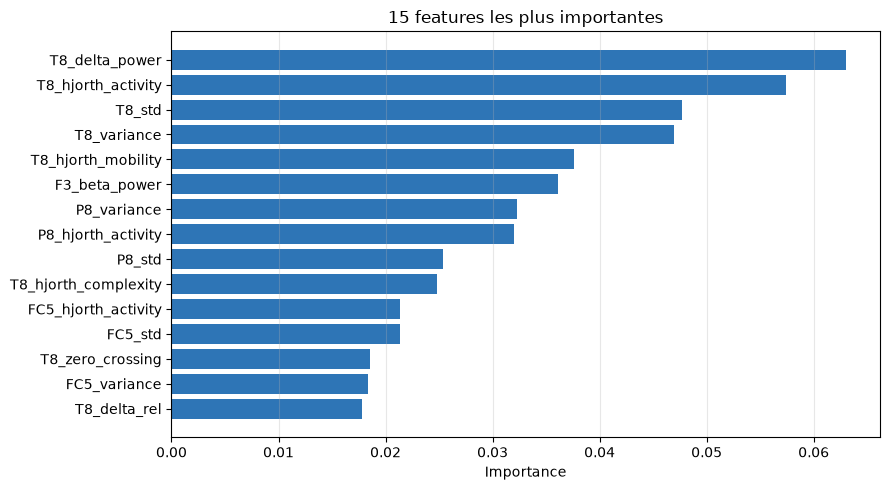

             feature  importance
      T8_delta_power    0.063043
  T8_hjorth_activity    0.057441
              T8_std    0.047684
         T8_variance    0.046963
  T8_hjorth_mobility    0.037625
       F3_beta_power    0.036066
         P8_variance    0.032282
  P8_hjorth_activity    0.031980
              P8_std    0.025378
T8_hjorth_complexity    0.024790
 FC5_hjorth_activity    0.021376
             FC5_std    0.021351
    T8_zero_crossing    0.018580
        FC5_variance    0.018316
        T8_delta_rel    0.017812


In [7]:
top = model.top_feature_importances(final_model, feature_names, top=15)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top["feature"][::-1], top["importance"][::-1], color="#2E75B6")
ax.set_xlabel("Importance")
ax.set_title("15 features les plus importantes")
ax.grid(True, alpha=0.3, axis="x")
fig.tight_layout()
plt.show()

print(top.to_string(index=False))

## ✅ Bilan du Sprint 4 — Jalon M1 atteint

À ce stade, on a :
- entraîné un modèle (Random Forest dans un pipeline avec normalisation) ;
- évalué **honnêtement** par sujet (LOSO), avec macro-F1, matrice de confusion et stabilité ;
- comparé à une référence naïve ;
- entraîné et **sauvegardé** le modèle final (`models/model.joblib`) ;
- identifié les features les plus utiles.

**Note d'honnêteté :** sur de vraies données EEG, un macro-F1 entre 0,6 et 0,8 est un **bon** résultat. Un score proche de 1,0 sur peu de sujets doit éveiller la méfiance (sur-apprentissage ou fuite). Ce qui compte, c'est un score honnêtement obtenu par validation par sujet.

**Prochaine étape (Sprint 5)** : l'application web Streamlit qui assemble toute la chaîne — l'utilisateur charge un fichier, le modèle prédit, l'interface affiche le résultat. C'est le jalon M2 et vos 80 %.